In [2]:
import re
import pandas as pd
import dotenv
import os
from neo4j import GraphDatabase

In [3]:
path_yahoo = "../data/TRIPLETS_yahoo.csv"
path_gfmag = "../data/TRIPLETS_ALL_gfmag.csv"
env_file = "../Neo4j_private.txt"

In [33]:
df_yahoo = pd.read_csv(path_yahoo)
df_gfmag = pd.read_csv(path_gfmag)

In [34]:
df_combined = pd.concat([df_yahoo, df_gfmag], ignore_index=True)

In [4]:
df_path = "../data/TRIPLETS_final_linked.csv"

In [5]:
linked = pd.read_csv(df_path)

In [48]:
linked = linked.drop(columns={'Unnamed: 0'})

In [11]:
linked.to_csv( "../data/TRIPLETS_final_linked.csv", index=False)

In [12]:
linked.shape

(99045, 8)

# clear neo4j 

In [26]:
dotenv.load_dotenv(env_file)

True

In [27]:
from neo4j import GraphDatabase

dotenv.load_dotenv(env_file)
URI = os.getenv("NEO4J_URI")
USER = os.getenv("NEO4J_USERNAME")
PWD = os.getenv("NEO4J_PASSWORD")

driver = GraphDatabase.driver(URI, auth=(USER, PWD))

with driver.session() as session:
    session.run("MATCH (n) DETACH DELETE n")

driver.close()

# ------

In [18]:
df = pd.read_csv(triplets_df_path)

In [9]:
#df.loc[
#    (df['entity1_type'] == 'country')]["entity1"].unique()

In [19]:
def to_camel_case(s: str) -> str:
    return ''.join(word.capitalize() for word in s.split('_'))


In [20]:
df['entity2_type'] = df['entity2_type'].apply(to_camel_case)
df['entity1_type'] = df['entity1_type'].apply(to_camel_case)


In [21]:
df.loc[
    (df['entity1_type'] == 'Country') |
    (df['entity2_type'] == 'Country')
] 

,entity1,entity1_type,rel_type,entity2,entity2_type,sector,url,date
14,First Iraqi Bank,Company,is_member_of,Iraq,Country,financials,https://gfmag.com/executive-interviews/complia...,2025-12-30T15:24:25+00:00
16,First Iraqi Bank,Company,has_positive_impact,Iraq,Country,financials,https://gfmag.com/executive-interviews/complia...,2025-12-30T15:24:25+00:00
18,First Iraqi Bank,Company,has_positive_impact,Iraq,Country,financials,https://gfmag.com/executive-interviews/complia...,2025-12-30T15:24:25+00:00
20,First Iraqi Bank,Company,has_positive_impact,Iraq,Country,financials,https://gfmag.com/executive-interviews/complia...,2025-12-30T15:24:25+00:00
28,Financial Action Task Force,Regulator,controls,South Africa,Country,financials,https://gfmag.com/news/fatf-removes-4-countrie...,2025-12-19T17:47:20+00:00
...,...,...,...,...,...,...,...,...
30783,Singapore,Country,is_member_of,Asean economic region,EconomicIndicator,public_sector,https://gfmag.com/data/shifting-fortunes/,2017-07-21T00:00:00+00:00
30784,Singapore,Country,is_member_of,Association of Southeast Asian Nations,EconomicIndicator,public_sector,https://gfmag.com/data/shifting-fortunes/,2017-07-21T00:00:00+00:00
30785,Singapore,Country,is_member_of,Asean economic region,EconomicIndicator,public_sector,https://gfmag.com/data/shifting-fortunes/,2017-07-21T00:00:00+00:00
30786,Singapore,Country,is_member_of,Association of Southeast Asian Nations,EconomicIndicator,public_sector,https://gfmag.com/data/shifting-fortunes/,2017-07-21T00:00:00+00:00


In [83]:
import pycountry

In [56]:
pycountry.countries.lookup("AI").name

'Anguilla'

In [73]:
def normalize_countries(name: str, entity_type: str):
    """
    Conservative country normalization.
    Never upgrades non-country entities.
    """
    cleaned = re.sub(r"[^\w\s]", "", name)
    cleaned = re.sub(r"\s+", " ", cleaned).strip()

    if entity_type != "Country":
        return cleaned, entity_type
    try:
        country = pycountry.countries.lookup(cleaned)
        return country.name, "Country"
    except:
        return cleaned, "Other"

In [72]:
e1_name, e1_type

('Nicaragua', 'country')

In [63]:
country = pycountry.countries.lookup("AI")

In [64]:
country

Country(alpha_2='AI', alpha_3='AIA', flag='🇦🇮', name='Anguilla', numeric='660')

In [65]:
country.name

'Anguilla'

In [16]:
df.dropna(subset=["entity1", "entity2"], inplace=True)

In [87]:
df[["entity1", "entity1_type"]] = df.apply(
    lambda row: normalize_countries(row["entity1"], row["entity1_type"]),
    axis=1,
    result_type="expand"
)
df[["entity2", "entity2_type"]] = df.apply(
    lambda row: normalize_countries(row["entity2"], row["entity2_type"]),
    axis=1,
    result_type="expand"
)

In [22]:
df.to_csv("../data/TRIPLETS_ALL.csv", index=False)

In [95]:
df.loc[df["rel_type"]=="invests_in"]

,entity1,entity1_type,rel_type,entity2,entity2_type,sector,url,date
10,corporates,company,invests_in,digital tools,product_service,technology,https://gfmag.com/executive-interviews/standar...,2025-12-31T18:00:00+00:00
22,Mirae Asset Securities,company,invests_in,artificial intelligence,product_service,technology,https://gfmag.com/banking/mirae-asset-securiti...,2025-12-16T11:02:48+00:00
58,Qatar Investment Authority,financial_institution,invests_in,Anthropic,company,technology,https://gfmag.com/features/qatar-new-world-cap...,2025-12-10T20:41:50+00:00
59,Qatar Investment Authority,financial_institution,invests_in,Applied Intuition,company,technology,https://gfmag.com/features/qatar-new-world-cap...,2025-12-10T20:41:50+00:00
181,Banks,financial_institution,invests_in,Private credit,financial_instrument,financials,https://gfmag.com/banking/familiar-bedfellows/,2025-10-08T15:04:07+00:00
...,...,...,...,...,...,...,...,...
30624,FAB,financial_institution,invests_in,cash management and liquidity solutions,product_service,financials,https://gfmag.com/award/best-treasury-cash-man...,2024-07-26T15:37:10+00:00
30720,Citi,financial_institution,invests_in,cloudbased flexible microservices,product_service,technology,https://gfmag.com/executive-interviews/reaping...,2023-09-03T00:00:00+00:00
30772,Nordea Bank,financial_institution,invests_in,blockchain,financial_instrument,technology,https://gfmag.com/executive-interviews/nordea-...,2019-12-09T00:00:00+00:00
30790,Data Collective venture capital fund,financial_institution,invests_in,Merlon Intelligence,company,financials,https://gfmag.com/data/can-technology-ensure-c...,2017-07-21T00:00:00+00:00


In [15]:
import time
import pandas as pd
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options

BASE_URL = "https://finance.yahoo.com/news/"
DELAY_SEC = 1.0  # polite delay between scrolls

def collect_yahoo_news_selenium(max_articles=5000, out_csv="yahoo_news_selenium.csv"):
    # Configure Chrome for headless mode
    chrome_options = Options()
    chrome_options.add_argument("--headless=new")  # runs Chrome in headless mode
    chrome_options.add_argument("--disable-gpu")
    chrome_options.add_argument("--window-size=1920,1080")

    driver = webdriver.Chrome(options=chrome_options)
    driver.get(BASE_URL)
    time.sleep(3)  # wait for initial content to load

    seen = set()
    rows = []

    last_height = driver.execute_script("return document.body.scrollHeight")
    scroll_attempts = 0

    while len(seen) < max_articles and scroll_attempts < 200:
        # collect links
        anchors = driver.find_elements(By.XPATH, '//a[contains(@href, "/news/")]')
        for a in anchors:
            url = a.get_attribute("href")
            if url not in seen:
                seen.add(url)
                rows.append({"Url": url})
                print(f"Collected {len(seen)} articles", end="\r")

        # scroll down
        driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
        time.sleep(DELAY_SEC)

        new_height = driver.execute_script("return document.body.scrollHeight")
        if new_height == last_height:
            scroll_attempts += 1  # stop after a few scrolls without new content
        else:
            scroll_attempts = 0
            last_height = new_height

    driver.quit()

    df = pd.DataFrame(rows[:max_articles])
    df["Text"] = ""
    df["Date"] = ""
    df.to_csv(out_csv, index=False)
    print(f"\nSaved {len(df)} articles to {out_csv}")


if __name__ == "__main__":
    collect_yahoo_news_selenium(max_articles=500, out_csv="yahoo_news_test.csv")


Defaulting to user installation because normal site-packages is not writeable


In [34]:
import re
import csv
from time import sleep
from bs4 import BeautifulSoup
import requests

In [37]:
import requests

url = "https://finance.yahoo.com/news/"
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
}

response = requests.get(url, headers=headers)
print("Status:", response.status_code)
print(response.text[:500])  # print the first 500 characters for inspection


Status: 200
<!doctype html>
<html lang="en-US" theme="auto" data-color-theme-enabled="true" data-color-scheme="auto" class="desktop neo-green dock-upscale">
    <head>
        <meta charset="utf-8" />
        <meta name="oath:guce:consent-host" content="guce.yahoo.com" />
        <link rel="preconnect" href="//s.yimg.com" crossorigin="anonymous"><link rel="preconnect" href="//geo.yahoo.com"/><link rel="preconnect" href="//query1.finance.yahoo.com"/><link rel="preconnect" href="//consent.cmp.oath.com"/><link


In [38]:
html = requests.get(url, headers=headers).text
soup = BeautifulSoup(html, "html.parser")

lis = soup.find_all("li")
print("Total <li> tags:", len(lis))

Total <li> tags: 815


In [54]:
tickers_df = pd.read_csv("tickerssp500.csv")
tickers = list(tickers_df["Symbol"].str.lower())

In [58]:
import requests
from bs4 import BeautifulSoup

rss_base = "https://feeds.finance.yahoo.com/rss/2.0/headline"

headers = {"User-Agent": "Mozilla/5.0"}
all_links = set()

for ticker in tickers:
    url = f"{rss_base}?s={ticker}&region=US&lang=en-US"
    r = requests.get(url, headers=headers)
    soup = BeautifulSoup(r.content, "xml")
    for item in soup.find_all("item"):
        all_links.add(item.link.text)


In [60]:
df = pd.DataFrame(list(all_links), columns=["link"])
df.to_csv("yahoo_links.csv", index=False)

In [61]:
import requests
from bs4 import BeautifulSoup

url = "https://finance.yahoo.com/news/3m-company-stock-wall-street-150707139.html"
headers = {
    "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/144.0.0.0 Safari/537.36"
}

response = requests.get(url, headers=headers)
print("Status:", response.status_code)

html = response.text
soup = BeautifulSoup(html, "html.parser")


Status: 200


In [65]:
# Find all paragraph tags
paragraphs = soup.find_all("p")

# Join text
article_text = "\n".join(p.get_text(strip=True) for p in paragraphs)

print(article_text[:2000])  # preview first 1000 chars

Oops, something went wrong
Saint Paul, Minnesota-based 3M Company (MMM) is a diversified technology company with a market cap of $81.4 billion. It develops a wide range of products serving industrial, safety, consumer, and electronics markets.
This industrial company has underperformed the broader market over the past 52 weeks. Shares of MMM have gained marginally over this time frame, while the broader S&P 500 Index ($SPX) has surged 14.3%. Moreover, on a YTD basis, the stock is down 4.4%, compared to SPX’s 1.4% uptick.
Chevron Hikes Its Dividend - But It's Less Than Expected - Is CVX Stock Fully Valued?
Before Amazon Invests $50 Billion in OpenAI, How Should You Play AMZN Stock?
Commodity Volatility, Earnings and Other Key Things to Watch
Stop Missing Market Moves: Get the FREE Barchart Brief – your midday dose of stock movers, trending sectors, and actionable trade ideas, delivered right to your inbox. Sign Up Now!
Narrowing the focus, MMM has also lagged behind the State Street Ind

## type-aware rgcn

In [1]:
from helpers.dataloader import load_graph_gcnn

df_path = "../data/TRIPLETS_final_linked.csv"
data = load_graph_gcnn(df_path, add_inverse=True)

In [2]:
data["df"]

,entity1,entity1_type,rel_type,entity2,entity2_type,sector,h,t,r,s
0,Alphabet,company,invests_in,AI,product_service,technology,0,1387,0,0
1,Alphabet,company,invests_in,data centers,product_service,technology,0,13660,0,0
2,Alphabet,company,invests_in,custom chips,product_service,technology,0,13661,0,0
3,Alphabet,company,invests_in,clean energy,natural_resource,energy,0,13662,0,1
4,Alphabet,company,partners_with,Apple,company,technology,0,112,1,0
...,...,...,...,...,...,...,...,...,...,...
79778,Sibos conference,other,has_positive_impact,technology,industry,technology,5345,5476,3,0
79779,Sibos conference,other,has_positive_impact,institutional cultural transformation,industry,public_sector,5345,40040,3,3
79780,Sibos conference,other,has_positive_impact,cyberthreats,industry,technology,5345,40041,3,0
79781,Sibos conference,other,has_positive_impact,data management,industry,technology,5345,20959,3,0


In [3]:
import torch

edge_index = data["edge_index"]
edge_type = data["edge_type"]

num_nodes = data["num_nodes"]
num_relations = data["num_relations"]
num_types = data["num_types"]

df = data["df"]

triples = torch.tensor(
    df[["h", "r", "t"]].values,  # remove 's'
    dtype=torch.long
)


seed = 11
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)

perm = torch.randperm(len(triples))
triples = triples[perm]

n = len(triples)
train_triples = triples[:int(0.8*n)]
val_triples   = triples[int(0.8*n):int(0.9*n)]
test_triples  = triples[int(0.9*n):]

In [4]:
train_triples

tensor([[  771,     3, 25582],
        [ 2927,     5, 20579],
        [ 4779,     2, 26993],
        ...,
        [ 1706,     2, 23017],
        [ 1045,     3, 15737],
        [ 3475,     3, 16541]])

In [5]:
# get relation column
relations = train_triples[:, 1]

# count unique values
unique_rels, counts = torch.unique(relations, return_counts=True)

rel_counts = dict(zip(unique_rels.tolist(), counts.tolist()))
print(rel_counts)

{0: 1240, 1: 425, 2: 12356, 3: 22329, 4: 1393, 5: 8886, 6: 7667, 7: 1245, 8: 6356, 9: 1381, 10: 361, 11: 18, 12: 169}


In [25]:
#aware
per_relation_metrics_aware = {
    0: {
        'MRR': 0.04959269160078975,
        'Hits@1': 0.014388489208633094,
        'Hits@3': 0.03597122302158273,
        'Hits@10': 0.11510791366906475,
        'support': 139
    },
    1: {
        'MRR': 0.07916966485917447,
        'Hits@1': 0.04081632653061224,
        'Hits@3': 0.08163265306122448,
        'Hits@10': 0.14285714285714285,
        'support': 49
    },
    2: {
        'MRR': 0.13645632136933702,
        'Hits@1': 0.07682375726275016,
        'Hits@3': 0.1433182698515171,
        'Hits@10': 0.2621045836023241,
        'support': 1549
    },
    3: {
        'MRR': 0.06872349529727392,
        'Hits@1': 0.023809523809523808,
        'Hits@3': 0.06601731601731602,
        'Hits@10': 0.1497113997113997,
        'support': 2772
    },
    4: {
        'MRR': 0.021189782214012333,
        'Hits@1': 0.0,
        'Hits@3': 0.012578616352201259,
        'Hits@10': 0.050314465408805034,
        'support': 159
    },
    5: {
        'MRR': 0.08632885478594615,
        'Hits@1': 0.04061371841155235,
        'Hits@3': 0.08754512635379061,
        'Hits@10': 0.18140794223826714,
        'support': 1108
    },
    6: {
        'MRR': 0.05527436733901754,
        'Hits@1': 0.02423603793466807,
        'Hits@3': 0.044257112750263436,
        'Hits@10': 0.11380400421496312,
        'support': 949
    },
    7: {
        'MRR': 0.04593210828237528,
        'Hits@1': 0.005714285714285714,
        'Hits@3': 0.05142857142857143,
        'Hits@10': 0.09714285714285714,
        'support': 175
    },
    8: {
        'MRR': 0.06100518285068212,
        'Hits@1': 0.026004728132387706,
        'Hits@3': 0.057919621749408984,
        'Hits@10': 0.12529550827423167,
        'support': 846
    },
    9: {
        'MRR': 0.07281333115537288,
        'Hits@1': 0.03592814371257485,
        'Hits@3': 0.0658682634730539,
        'Hits@10': 0.1377245508982036,
        'support': 167
    },
    10: {
        'MRR': 0.0691023967261673,
        'Hits@1': 0.022727272727272728,
        'Hits@3': 0.06818181818181818,
        'Hits@10': 0.1590909090909091,
        'support': 44
    },
    12: {
        'MRR': 0.07650411136126234,
        'Hits@1': 0.045454545454545456,
        'Hits@3': 0.045454545454545456,
        'Hits@10': 0.18181818181818182,
        'support': 22
    }
}

In [26]:
#unaware
per_relation_metrics_unaware = {
    0: {
        'MRR': 0.08030461712947325,
        'Hits@1': 0.04316546762589928,
        'Hits@3': 0.07913669064748201,
        'Hits@10': 0.14388489208633093,
        'support': 139
    },
    1: {
        'MRR': 0.023007518653067972,
        'Hits@1': 0.0,
        'Hits@3': 0.02040816326530612,
        'Hits@10': 0.04081632653061224,
        'support': 49
    },
    2: {
        'MRR': 0.13643285284795928,
        'Hits@1': 0.06907682375726275,
        'Hits@3': 0.14525500322788895,
        'Hits@10': 0.27307940606843123,
        'support': 1549
    },
    3: {
        'MRR': 0.06372071535293167,
        'Hits@1': 0.026695526695526696,
        'Hits@3': 0.05519480519480519,
        'Hits@10': 0.11940836940836941,
        'support': 2772
    },
    4: {
        'MRR': 0.015425310978606511,
        'Hits@1': 0.0,
        'Hits@3': 0.006289308176100629,
        'Hits@10': 0.03773584905660377,
        'support': 159
    },
    5: {
        'MRR': 0.07396762054188347,
        'Hits@1': 0.03429602888086643,
        'Hits@3': 0.07129963898916968,
        'Hits@10': 0.1444043321299639,
        'support': 1108
    },
    6: {
        'MRR': 0.039164034931552294,
        'Hits@1': 0.009483667017913594,
        'Hits@3': 0.022128556375131718,
        'Hits@10': 0.09799789251844046,
        'support': 949
    },
    7: {
        'MRR': 0.04521239981515454,
        'Hits@1': 0.011428571428571429,
        'Hits@3': 0.045714285714285714,
        'Hits@10': 0.10285714285714286,
        'support': 175
    },
    8: {
        'MRR': 0.05345696757124385,
        'Hits@1': 0.018912529550827423,
        'Hits@3': 0.04609929078014184,
        'Hits@10': 0.11347517730496454,
        'support': 846
    },
    9: {
        'MRR': 0.035954390204293085,
        'Hits@1': 0.017964071856287425,
        'Hits@3': 0.029940119760479042,
        'Hits@10': 0.059880239520958084,
        'support': 167
    },
    10: {
        'MRR': 0.018062957878167096,
        'Hits@1': 0.0,
        'Hits@3': 0.0,
        'Hits@10': 0.022727272727272728,
        'support': 44
    },
    12: {
        'MRR': 0.2171282616863123,
        'Hits@1': 0.18181818181818182,
        'Hits@3': 0.22727272727272727,
        'Hits@10': 0.3181818181818182,
        'support': 22
    }
}

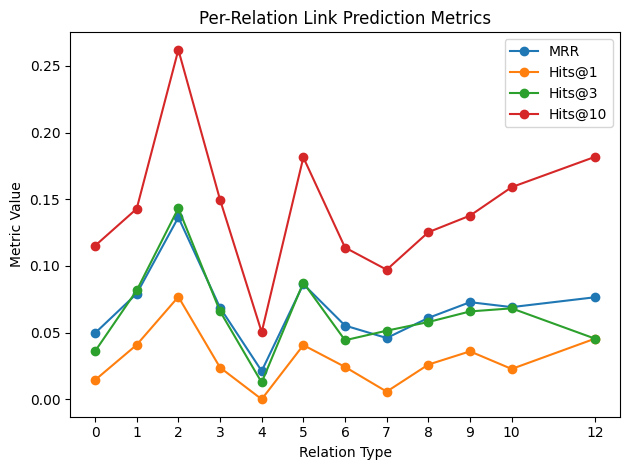

In [27]:
import matplotlib.pyplot as plt

def plot_per_relation_metrics(per_relation_metrics):
    # Sort relations for consistent ordering
    relations = sorted(per_relation_metrics.keys())

    mrr = [per_relation_metrics[r]['MRR'] for r in relations]
    hits1 = [per_relation_metrics[r]['Hits@1'] for r in relations]
    hits3 = [per_relation_metrics[r]['Hits@3'] for r in relations]
    hits10 = [per_relation_metrics[r]['Hits@10'] for r in relations]

    plt.figure()
    plt.plot(relations, mrr, marker='o', label='MRR')
    plt.plot(relations, hits1, marker='o', label='Hits@1')
    plt.plot(relations, hits3, marker='o', label='Hits@3')
    plt.plot(relations, hits10, marker='o', label='Hits@10')

    plt.xlabel("Relation Type")
    plt.ylabel("Metric Value")
    plt.title("Per-Relation Link Prediction Metrics")
    plt.legend()
    plt.xticks(relations)
    plt.tight_layout()
    plt.show()


# usage
plot_per_relation_metrics(per_relation_metrics_aware)

In [16]:
import matplotlib.pyplot as plt
import numpy as np

def plot_frequency_vs_mrr(rel_counts, per_relation_metrics):
    x = []
    y = []
    labels = []

    for rel_id, metrics in per_relation_metrics.items():
        if rel_id in rel_counts:
            x.append(rel_counts[rel_id])
            y.append(metrics['MRR'])
            labels.append(rel_id)

    x = np.array(x)
    y = np.array(y)

    # Log-transform frequency for correlation
    log_x = np.log(x)

    # Correlation
    corr = np.corrcoef(log_x, y)[0, 1]
    print(f"Correlation (log frequency vs MRR): {corr:.4f}")

    plt.figure()
    plt.scatter(x, y)

    # Regression line (on log-scale)
    slope, intercept = np.polyfit(log_x, y, 1)
    x_line = np.linspace(min(x), max(x), 100)
    y_line = slope * np.log(x_line) + intercept
    plt.plot(x_line, y_line)

    # Move labels slightly right & up
    x_offset = x * 0.05  # 5% shift to the right
    y_offset = 0.002     # small vertical shift

    for i, rel_id in enumerate(labels):
        plt.text(x[i] + x_offset[i], y[i] + y_offset, str(rel_id))

    plt.xscale("log")
    plt.xlabel("Training Relation Frequency (log scale)")
    plt.ylabel("MRR")
    plt.title("Relation Frequency vs MRR")

    plt.tight_layout()
    plt.show()

Correlation (log frequency vs MRR): -0.1098


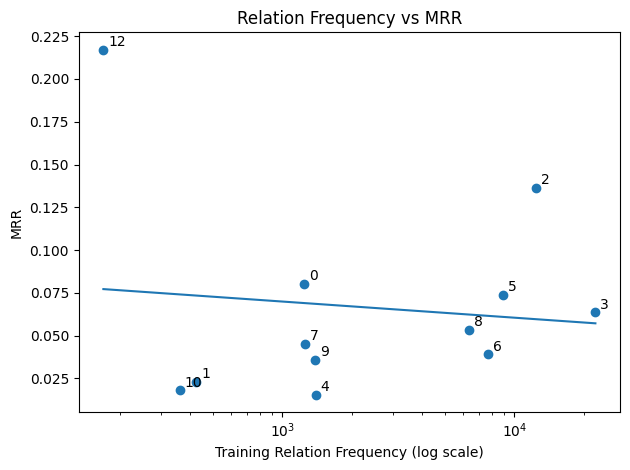

In [17]:
plot_frequency_vs_mrr(rel_counts, per_relation_metrics)